1\. Рассмотрите пример работы слоя `ConvTranspose2d`.

In [ ]:
import torch
import torch.nn as nn

In [ ]:
in_channels = 1
out_channels = 1
kernel_size = 3
stride = 2
padding = 1
output_padding = 1

In [ ]:
deconv = nn.ConvTranspose2d(
    in_channels=in_channels,
    out_channels=out_channels,
    kernel_size=kernel_size,
    stride=stride,
    padding=padding,
    output_padding=output_padding
)

In [ ]:
x = torch.randn(1, 1, 4, 4)
print("Input shape:", x.shape)

Input shape: torch.Size([1, 1, 4, 4])


In [ ]:
y = deconv(x)
print("Output shape:", y.shape)

Output shape: torch.Size([1, 1, 8, 8])


<p class="task" id="1"></p>

1\. Опишите датасет `ClothesSegmentationDataset`. Реализуйте `__getitem__` таким образом, чтобы он возвращал два элемента: тензор с изображением и тензор с маской. Маска должна быть представлена трехмерным тензором целых чисел. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений и масок. Создайте объект датасета и выведите на экран форму и типы одного изображения и его маски.

- [ ] Проверено на семинаре

In [ ]:
import os
import zipfile
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()
zip_path = next(iter(uploaded))

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

Saving archive.zip to archive.zip


In [ ]:
train_images_path = '/content/clothes_dataset/Train/Image'
train_masks_path = '/content/clothes_dataset/Train/Mask'

In [ ]:
print("Примеры изображений:", os.listdir(train_images_path)[:3])
print("Примеры масок:", os.listdir(train_masks_path)[:3])

Примеры изображений: ['8260.jpg', '189.jpg', '8349.jpg']
Примеры масок: ['12109.jpg.png', '12202.jpg.png', '4503.jpg.png']


In [ ]:
class ClothesSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.image_filenames = sorted(os.listdir(images_dir))
        self.mask_filenames = sorted(os.listdir(masks_dir))

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.masks_dir, self.mask_filenames[idx])

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        if self.image_transform:
            image = self.image_transform(image)
        else:
            image = T.ToTensor()(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = torch.from_numpy(np.array(mask)).long().unsqueeze(0)

        return image, mask

In [ ]:
image_transforms = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

mask_transforms = T.Compose([
    T.Resize((256, 256), interpolation=Image.NEAREST),
    T.Lambda(lambda x: torch.from_numpy(np.array(x)).long().unsqueeze(0))
])

In [ ]:
dataset = ClothesSegmentationDataset(
    images_dir=train_images_path,
    masks_dir=train_masks_path,
    image_transform=image_transforms,
    mask_transform=mask_transforms
)

In [ ]:
image, mask = dataset[0]
print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")

Image shape: torch.Size([3, 256, 256]), dtype: torch.float32
Mask shape: torch.Size([1, 256, 256, 4]), dtype: torch.int64


<p class="task" id="2"></p>

2\. Напишите функцию `show_image_with_mask`, которая выводит рядом два изображения: фотографию и маску. Продемонстрируйте работу функции, взяв один пример из созданного датасета.

- [ ] Проверено на семинаре

In [ ]:
def show_image_with_mask(image, mask):
    image_np = image.permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze(0).cpu().numpy()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask_np, cmap='jet')
    plt.title('Mask')
    plt.axis('off')
    plt.show()

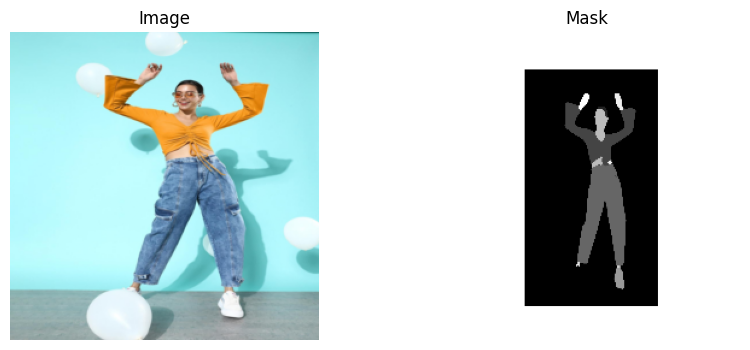

In [ ]:
show_image_with_mask(image, mask)

<p class="task" id="3"></p>

3\. Реализуйте архитектуру U-Net. Реализуйте модель таким образом, чтобы на выходе для каждого изображения получался тензор размера `n_classes x h x w`, где `n_classes` - количество уникальных значений в масках, а `h` и `w` - размер исходного изображения. Возьмите один пример из набора данных и пропустите его через сеть. Выведите форму полученного результата на экран.

- [ ] Проверено на семинаре

In [ ]:
import torch.nn.functional as F

In [ ]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=2, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024 // (2 if bilinear else 1))
        self.up1 = Up(1024, 512 // (2 if bilinear else 1), bilinear)
        self.up2 = Up(512, 256 // (2 if bilinear else 1), bilinear)
        self.up3 = Up(256, 128 // (2 if bilinear else 1), bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [ ]:
n_classes = len(torch.unique(mask))

In [ ]:
model = UNet(n_channels=3, n_classes=n_classes)

In [ ]:
image, mask = dataset[0]
image = image.unsqueeze(0)

In [ ]:
with torch.no_grad():
    output = model(image)

In [ ]:
print("Форма выходного тензора:", output.shape)

Форма выходного тензора: torch.Size([1, 91, 256, 256])


<p class="task" id="4"></p>

4\.  Разбейте набор данных на обучающее и валидационное множество. Обучите модель U-Net для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Обратите внимание, что выборка является несбалансированной. При расчете функции потерь примените любую известную вам технику для работы с несбалансированными выборками.

При создании датасета допускается использовать преобразования, уменьшающие размер изображений (для ускорения процесса обучения).

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре

In [ ]:
class ClothesSegmentationDataset(Dataset):
    def __init__(self, images_zip_path, masks_zip_path, image_folder_name="IMAGES", mask_folder_name="MASKS", transform=None):
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []

        self.extract_image_dir = "/content/unzipped_images"
        self.extract_mask_dir = "/content/unzipped_masks"
        os.makedirs(self.extract_image_dir, exist_ok=True)
        os.makedirs(self.extract_mask_dir, exist_ok=True)

        with zipfile.ZipFile(images_zip_path, 'r') as zip_ref:
            zip_ref.extractall(self.extract_image_dir)
        with zipfile.ZipFile(masks_zip_path, 'r') as zip_ref:
            zip_ref.extractall(self.extract_mask_dir)

        for root, _, files in os.walk(self.extract_image_dir):
            if os.path.basename(root) == image_folder_name:
                for file in sorted(files):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(root, file))

        for root, _, files in os.walk(self.extract_mask_dir):
            if os.path.basename(root) == mask_folder_name:
                for file in sorted(files):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.mask_paths.append(os.path.join(root, file))

        if len(self.image_paths) != len(self.mask_paths):
            raise ValueError("Количество изображений не совпадает с количеством масок.")

        self.image_paths.sort()
        self.mask_paths.sort()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        else:
            image = transforms.ToTensor()(image)
            mask = transforms.ToTensor()(mask)

        mask = (mask > 0).float()
        return image, mask


Image shape: torch.Size([3, 256, 256]) | dtype: torch.float32
Mask shape: torch.Size([1, 256, 256]) | dtype: torch.int64


In [ ]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.dec3 = conv_block(256, 128)
        self.dec2 = conv_block(128, 64)
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d3 = F.interpolate(e3, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(d3)

        d2 = F.interpolate(d3, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(d2)

        out = self.final(F.interpolate(d2, size=x.shape[2:], mode='bilinear', align_corners=False))
        return out


In [ ]:
def visualize_predictions(model, val_loader, device):
    model.eval()
    imgs, masks = next(iter(val_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = torch.sigmoid(model(imgs)) > 0.5

    for i in range(min(3, imgs.size(0))):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(imgs[i].cpu().permute(1, 2, 0))
        axs[0].set_title("Image")
        axs[1].imshow(masks[i].cpu().squeeze(), cmap='gray')
        axs[1].set_title("Ground Truth")
        axs[2].imshow(preds[i].cpu().squeeze(), cmap='gray')
        axs[2].set_title("Prediction")
        plt.show()


In [ ]:
import os, zipfile
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.dec3 = conv_block(256, 128)
        self.dec2 = conv_block(128, 64)
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d3 = F.interpolate(e3, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(d3)

        d2 = F.interpolate(d3, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(d2)

        out = F.interpolate(d2, size=x.shape[2:], mode='bilinear', align_corners=False)
        return self.final(out)

class DiceLoss(nn.Module):
    def forward(self, preds, targets, smooth=1):
        preds = torch.sigmoid(preds).view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        return 1 - ((2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth))

def calculate_accuracy(preds, targets):
    preds = (torch.sigmoid(preds) > 0.5).float()
    return (preds == targets).float().mean()

def train_model(images_zip_path, masks_zip_path, epochs=10):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])

    dataset = ClothesSegmentationDataset(images_zip_path, masks_zip_path, transform=transform)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = DiceLoss()

    for epoch in range(epochs):
        model.train()
        train_loss, train_acc = 0, 0
        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            acc = calculate_accuracy(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc.item()

        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, masks)
                acc = calculate_accuracy(outputs, masks)
                val_loss += loss.item()
                val_acc += acc.item()

        print(f"Epoch {epoch+1}: "
              f"Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc/len(train_loader):.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc/len(val_loader):.4f}")

    return model, val_loader


images_zip_path = "/content/jpeg_images.zip"
masks_zip_path = "/content/jpeg_masks.zip"
model, val_loader = train_model(images_zip_path, masks_zip_path, epochs=10)
visualize_predictions(model, val_loader, torch.device("cuda" if torch.cuda.is_available() else "cpu"))


Epoch 1 - Training: 100%|██████████| 200/200 [12:38<00:00,  3.79s/it]


Epoch 1: Train Loss: 0.5565, Acc: 0.4203 | Val Loss: 0.4332, Acc: 0.6930


Epoch 2 - Training: 100%|██████████| 200/200 [15:01<00:00,  4.51s/it]


Epoch 2: Train Loss: 0.3388, Acc: 0.7874 | Val Loss: 0.3123, Acc: 0.8143


Epoch 3 - Training: 100%|██████████| 200/200 [24:27<00:00,  7.34s/it]


...

Epoch 6 - Training: 100%|██████████| 200/200 [20:46<00:00,  6.23s/it]


Epoch 6: Train Loss: 0.2090, Acc: 0.8848 | Val Loss: 0.2095, Acc: 0.8959


Epoch 7 - Training: 100%|██████████| 200/200 [19:50<00:00,  5.95s/it]


Epoch 7: Train Loss: 0.1903, Acc: 0.8963 | Val Loss: 0.1912, Acc: 0.8999


Epoch 8 - Training:  36%|███▌      | 71/200 [07:23<14:34,  6.78s/it]